[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IbHansen/wb-debt-simulation/blob/main/optimization/currency.ipynb)

In [1]:
if 'google.colab' in str(get_ipython()):
    import os
    os.system('pip -qqq install ModelFlowIb')
    os.system('curl -L -o exchangerates_get.py https://raw.githubusercontent.com/IbHansen/wb-debt-simulation/main/optimization/exchangerates_get.py')

In [2]:
import pandas as pd
import numpy as np

import exchangerates_get as er

# Flip to True to force a fresh ECB download and overwrite the cache.
REFRESH = False

In [3]:
fx_eur = er.ecb_fx_eur(
    currencies=["USD", "GBP", "JPY", "CHF","EUR","ZAR"],
    start="2010-01-01",
    freq='Q',
    refresh=REFRESH,
)
#fx_eur    

In [4]:
# Step 2: express everything in base currency 
fx_ccy = er.convert_base_currency(fx_eur, base="zar")

fx_returns = er.get_fx_returns(fx_ccy)

# Step 3: annualised covariance matrix
# ECB data is fetched at quarterly frequency (freq='Q') → periods_per_year=4
# annual_cov  =  4 × quarterly_cov
# annual_std  =  √4 × quarterly_std  =  2 × quarterly_std
fx_cov = er.get_fx_covariance(fx_returns, periods_per_year=4)

In [5]:
fx_ccy

,ZAR_CHF,ZAR_GBP,ZAR_JPY,ZAR_USD,ZAR_EUR
TIME_PERIOD,,,,,
2010Q1,0.144316,0.089950,12.730232,0.136259,0.101090
2010Q2,0.141598,0.087141,11.597092,0.130810,0.106601
2010Q3,0.139221,0.090106,11.911398,0.143004,0.104780
2010Q4,0.141089,0.097123,12.259520,0.150770,0.112835
2011Q1,0.134757,0.091568,12.186681,0.147212,0.103619
...,...,...,...,...,...
2025Q2,0.044849,0.041049,8.117134,0.056235,0.047982
2025Q3,0.046169,0.043063,8.567202,0.057889,0.049305
2025Q4,0.047902,0.044878,9.467751,0.060430,0.051430


In [6]:
import numpy as np

fx_corr = er.get_fx_covariance(fx_returns, correlation=True)

# fx_cov is annualised (quarterly × 4) → std here is annual std
std = np.sqrt(np.diag(fx_cov.values))
std = pd.Series(std * 100, index=fx_cov.index, name="Annual std (%)")
print("Annual std (%) — note: quarterly std × 2 = annual std:")
print(std.to_string())
print()
print("Annual covariance matrix:")
display(fx_cov)

Annual std (%) — note: quarterly std × 2 = annual std:
ZAR_CHF    11.466991
ZAR_GBP    11.150873
ZAR_JPY    14.634711
ZAR_USD    13.660137
ZAR_EUR    11.293811

Annual covariance matrix:


,ZAR_CHF,ZAR_GBP,ZAR_JPY,ZAR_USD,ZAR_EUR
ZAR_CHF,0.013149,0.010440,0.012474,0.012501,0.011254
ZAR_GBP,0.010440,0.012434,0.011415,0.012187,0.010969
ZAR_JPY,0.012474,0.011415,0.021417,0.014392,0.011430
ZAR_USD,0.012501,0.012187,0.014392,0.018660,0.011684
ZAR_EUR,0.011254,0.010969,0.011430,0.011684,0.012755


ZAR_CHF    1146.699105
ZAR_GBP    1115.087278
ZAR_JPY    1463.471056
ZAR_USD    1366.013740
ZAR_EUR    1129.381149
Name: Annual std (%), dtype: float64


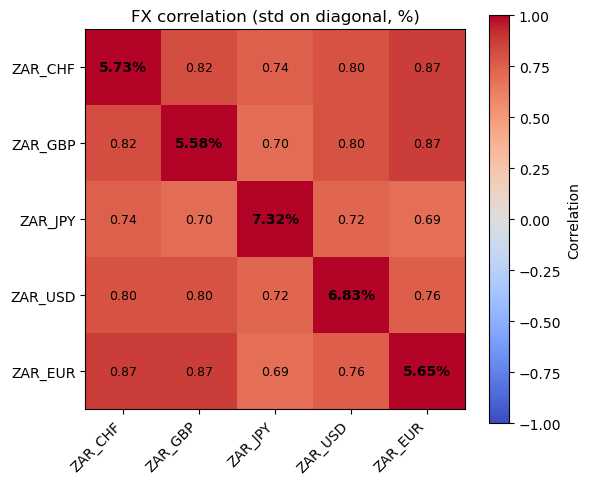

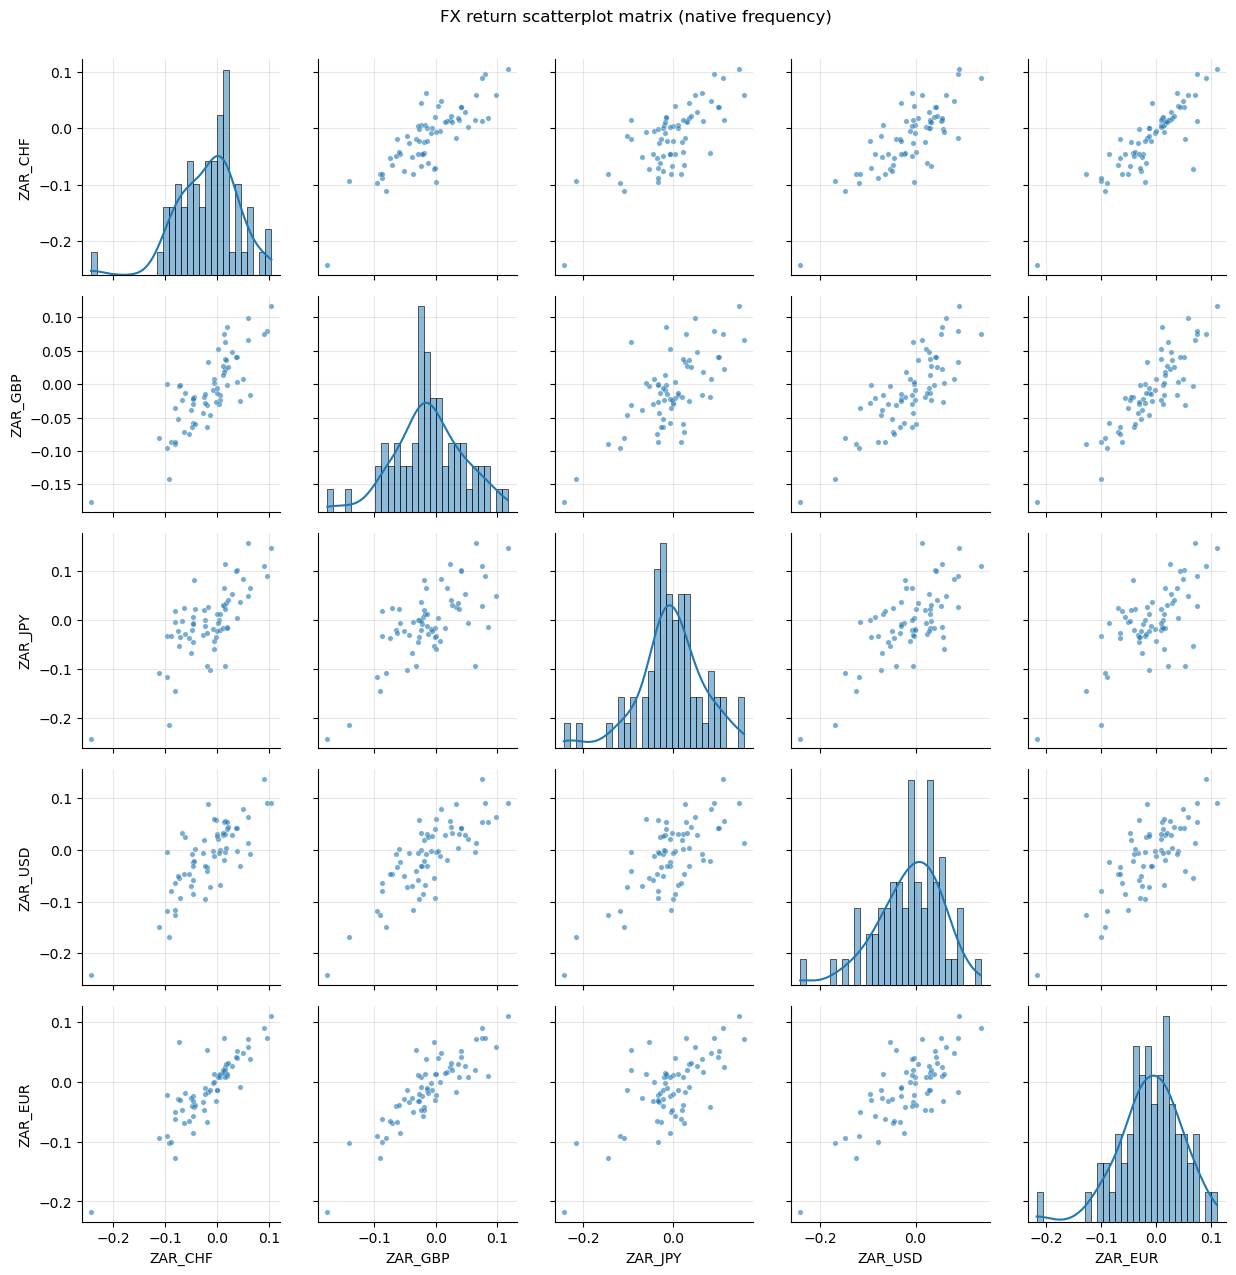

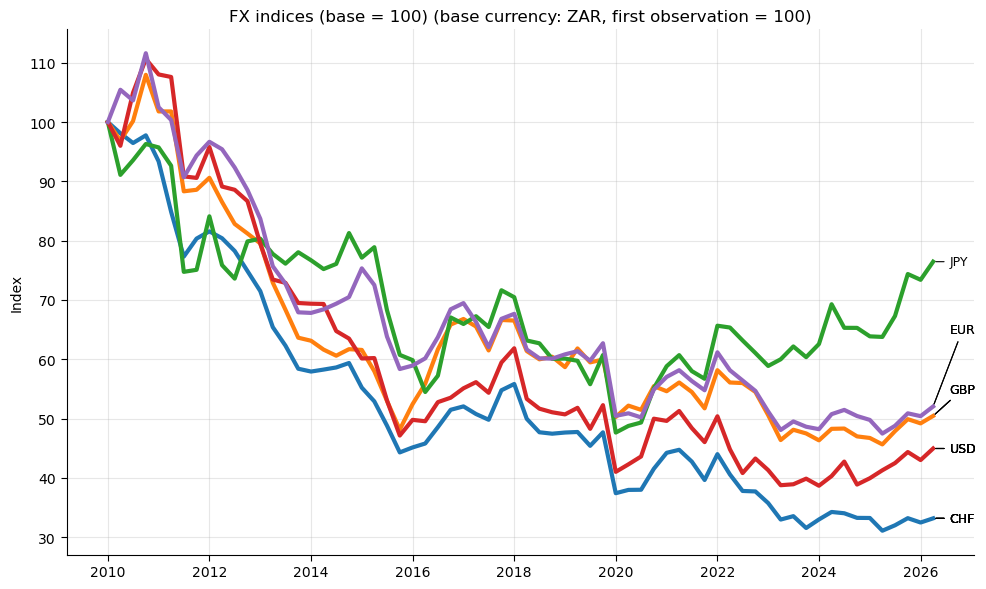

In [7]:
print(std*100)

er.plot_corr_with_std(
    fx_returns,
    title="FX correlation (std on diagonal, %)"
)


er.plot_return_scatter_matrix_with_marginals(
    fx_returns,
    title="FX return scatterplot matrix (native frequency)"
)
#%%
er.plot_indexed_fx(
    fx_ccy,
    min_label_gap=10.0

)

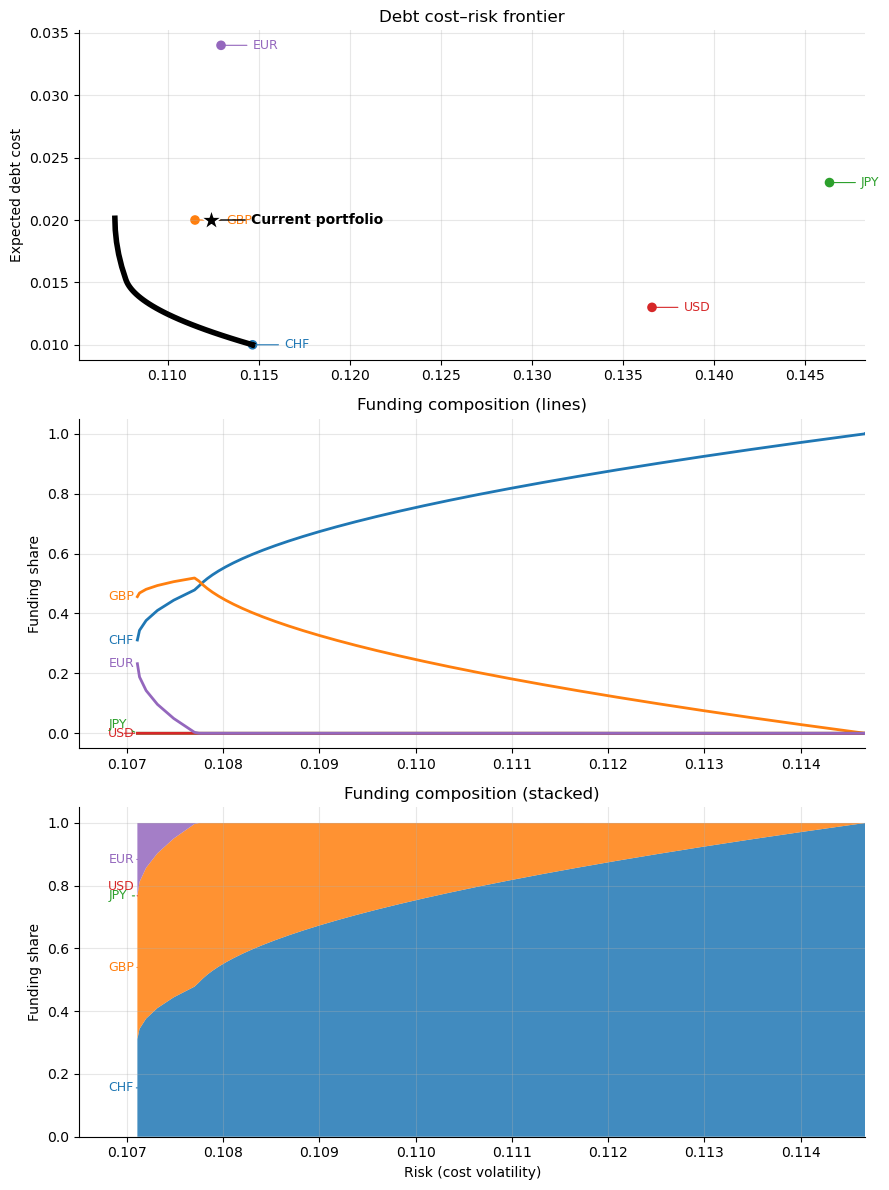

In [8]:
# cov_df is already annualised (quarterly × 4): risk axis is in annual units,
# consistent with the annual interest rates in the assumptions below.
cov_df = fx_cov.rename(
    index=lambda x: x.split('_')[1],
    columns=lambda x: x.split('_')[1],
)
names = cov_df.index

assumptions = pd.DataFrame(
    {
        'interest_rate':         [0.010, 0.020, 0.023, 0.013, 0.034],
        'expected_appreciation': [0.000, 0.000, 0.000, 0.000, 0.000],
        'min_share':             [0.0, 0.0, 0.0, 0.0, 0.0],
        'max_share':             [1.0, 1.0, 1.0, 1.0, 1.0],
        'current_share':         [0.2, 0.2, 0.2, 0.2, 0.2],
    },
    index=names,
)

res = er.mv_from_dataframes(cov_df=cov_df, assumptions=assumptions)

# row 0 = current composition; rows 1: = frontier
expected_cost = assumptions['interest_rate'] + assumptions['expected_appreciation']

er.plot_debt_frontier_labeled(
    res.iloc[1:].reset_index(drop=True),
    label_pos="start",
    cost_col="return",
    cost_s=expected_cost,
    cov_df=cov_df,
    current=res.iloc[0],
    export_path="zar_debt_frontier",
    export_formats=("png", "pdf", "svg"),
)

In [9]:
res


,risk,return,CHF,GBP,JPY,USD,EUR
0,0.112411,0.020000,0.200000,2.000000e-01,2.000000e-01,2.000000e-01,2.000000e-01
1,0.107110,0.020138,0.311426,4.562284e-01,3.263166e-05,7.515032e-07,2.323119e-01
2,0.107133,0.019195,0.343652,4.683514e-01,1.904682e-05,7.789435e-07,1.879767e-01
3,0.107201,0.018233,0.376530,4.807190e-01,1.269533e-05,8.100217e-07,1.427370e-01
4,0.107319,0.017251,0.410084,4.933396e-01,9.101129e-06,8.307577e-07,9.656659e-02
...,...,...,...,...,...,...,...
97,0.114670,0.010000,0.999998,2.037515e-08,2.820512e-08,2.098449e-06,3.203838e-08
98,0.114670,0.010000,0.999998,2.054232e-08,2.854873e-08,1.973510e-06,3.219966e-08
99,0.114670,0.010000,0.999998,2.068719e-08,2.879273e-08,1.845155e-06,3.222767e-08
100,0.114670,0.010000,0.999998,2.080268e-08,2.892876e-08,1.712575e-06,3.211296e-08


## Interactive inputs — `DebtFrontierInputs`

The cells below wrap the same covariance matrix and assumption frame in a `DebtFrontierInputs` dataclass and render an editable grid (currencies × input fields). Edit any cell, then press **Run frontier** to re-solve and re-plot. The dataclass's `assumptions` attribute always reflects the latest edits, so you can also drive `inputs.plot()` from code between clicks.

In [10]:
inputs = er.DebtFrontierInputs(cov_df=cov_df, assumptions=assumptions)
inputs.assumptions

,interest_rate,expected_appreciation,min_share,max_share,current_share
CHF,0.010,0.0,0.0,1.0,0.2
GBP,0.020,0.0,0.0,1.0,0.2
JPY,0.023,0.0,0.0,1.0,0.2
USD,0.013,0.0,0.0,1.0,0.2
EUR,0.034,0.0,0.0,1.0,0.2


In [11]:
inputs.widget()